# Impact des coûts de transaction sur le SMA — les 8 titres

Ce notebook reprend le graphique « courbes d'équité avec et sans coûts » du notebook 04, mais **sur les huit titres** (au lieu du seul AAPL), pour mieux voir l'effet des coûts titre par titre.

**Rappel du modèle de coûts.** Ici les coûts viennent du moteur événementiel (`SimulatedExecutionHandler`) : commission + slippage en **points de base appliqués sur le montant de chaque exécution**. C'est un modèle **proportionnel (linéaire)** — une fraction fixe du montant échangé. Il ne modélise pas l'impact de marché non linéaire, le demi-spread, les coûts fixes ou le coût d'emprunt : c'est une simplification standard, assumée comme limite.

In [1]:
import sys, queue; sys.path.insert(0, "../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from data import HistoricCSVDataHandler
from strategy import MovingAverageCrossStrategy
from portfolio import Portfolio
from execution import SimulatedExecutionHandler
from backtest import run_backtest

prices = pd.read_csv("../data/adj_close.csv", index_col=0, parse_dates=True)
UNIVERSE = ["AAPL", "MSFT", "NVDA", "AMZN", "JPM", "XOM", "JNJ", "PG"]

def run_sma(symbol, short=50, long=200, commission_bps=0.0, slippage_bps=0.0,
            initial_capital=100_000.0, target_pct=0.95):
    ev = queue.Queue()
    d = HistoricCSVDataHandler(ev, prices, [symbol]); d.events = ev
    s = MovingAverageCrossStrategy(d, ev, [symbol], short, long)
    p = Portfolio(d, ev, [symbol], prices.index[0], initial_capital, target_pct)
    x = SimulatedExecutionHandler(d, ev, commission_bps, slippage_bps)
    return run_backtest(d, s, p, x)

def sharpe(ec): 
    r = ec["returns"].dropna(); return r.mean()/r.std()*np.sqrt(252)

## 1. Courbes d'équité avec et sans coûts, un panneau par titre

Trois scénarios : sans coût, un coût réaliste (10 bps + 10 bps) et un coût **stressé** (50 bps + 50 bps) pour rendre l'effet visible. Chaque panneau indique le nombre de changements de position et la perte d'équité finale au coût réaliste.

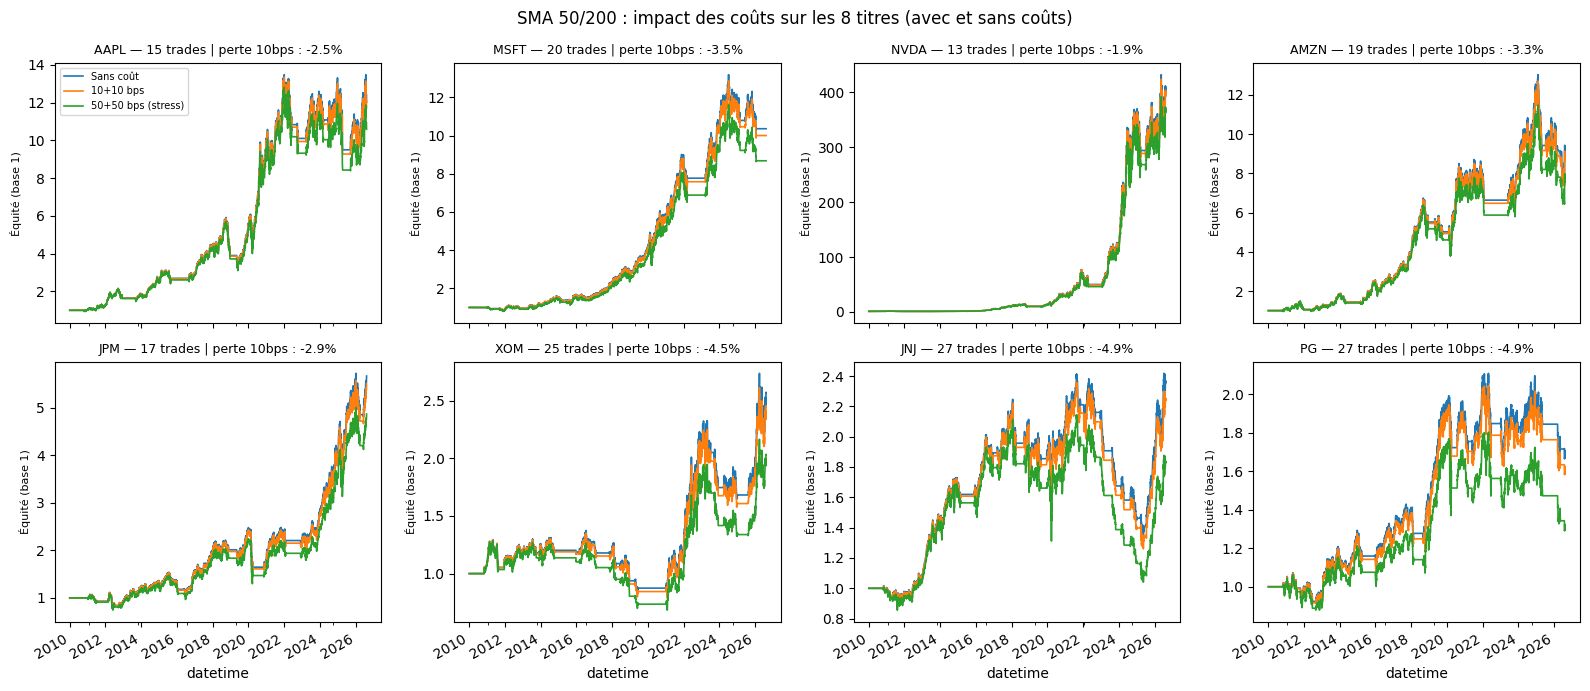

In [2]:
scen = {"Sans coût": (0, 0), "10+10 bps": (10, 10), "50+50 bps (stress)": (50, 50)}
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
brut_net = {}
for ax, t in zip(axes.ravel(), UNIVERSE):
    eqs = {}
    for lab, (cb, sb) in scen.items():
        ec = run_sma(t, 50, 200, cb, sb); eqs[lab] = ec["equity"]
        if lab == "Sans coût": pos = ec[f"pos_{t}"]
        if lab == "10+10 bps": eq_net = ec["equity"]
    brut_net[t] = (eqs["Sans coût"], eq_net)
    n_chg = int((pos.diff().abs() > 0).sum())
    perte = eq_net.iloc[-1] / eqs["Sans coût"].iloc[-1] - 1
    for lab, eq in eqs.items():
        (eq / eq.iloc[0]).plot(ax=ax, label=lab, lw=1.2)
    ax.set_title(f"{t} — {n_chg} trades | perte 10bps : {perte:.1%}", fontsize=9)
    ax.set_ylabel("Équité (base 1)", fontsize=8)
axes.ravel()[0].legend(fontsize=7)
fig.suptitle("SMA 50/200 : impact des coûts sur les 8 titres (avec et sans coûts)", fontsize=12)
plt.tight_layout(); plt.show()

## 2. Vue « loupe » : écart relatif net vs brut (10+10 bps)

Comme l'impact est faible, on trace directement l'**écart relatif** $ \text{équité}_{\text{net}} / \text{équité}_{\text{brut}} - 1 $ dans le temps. Cette vue magnifie la (petite) différence : la courbe descend par paliers, un palier par trade — c'est la signature d'un coût proportionnel au turnover.

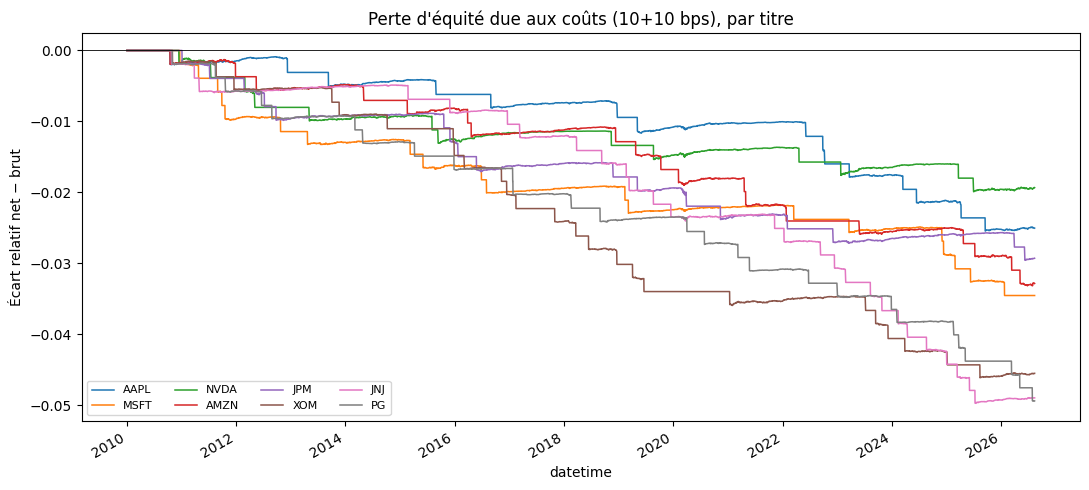

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
for t in UNIVERSE:
    brut, net = brut_net[t]
    (net / brut - 1).plot(ax=ax, label=t, lw=1.1)
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("Écart relatif net − brut"); ax.set_title("Perte d'équité due aux coûts (10+10 bps), par titre")
ax.legend(ncol=4, fontsize=8); plt.tight_layout(); plt.show()

## Ce qu'on retient

- Au coût **réaliste** (10+10 bps), l'impact reste **marginal** sur les huit titres : le SMA change rarement de position (une vingtaine de fois en seize ans), donc paie peu de coûts. C'est le résultat honnête, pas un artefact du choix d'AAPL.
- La vue « loupe » montre la **mécanique** : l'équité nette décroche par petits paliers, un par trade → le coût est bien **proportionnel au turnover**.
- Il faut un coût **stressé** (50 bps) pour voir l'effet à l'œil nu — ce qui confirme que, pour une stratégie à faible turnover comme le SMA, les coûts ne sont pas le facteur décisif (contrairement au momentum, qui tourne beaucoup).